# Evaluación Formativa 1: Análisis Estadístico Completo
## Caso Integrado: Logística y E-Commerce 📦

**Curso**: Estadística Computacional para la Toma de Decisiones  
**Magíster**: Ciencia de Datos e Inteligencia Artificial  
**Integrantes**: Jennifer Nilo - Patricio Núñez (Grupo 10)  
**Repositorio**: https://github.com/pnunezcarreno/grupo10-estadistica-unab

---

## 🎯 Contexto del Negocio y Problema de Decisión

Una empresa internacional de comercio electrónico enfrenta desafíos logísticos que impactan directamente en la satisfacción del cliente y sus costos operativos. Se requiere analizar un conjunto de datos históricos de aproximadamente 11,000 envíos para determinar qué factores inciden en el cumplimiento de las entregas.

**Preguntas de Investigación**:
1. ¿Cómo se distribuyen las variables clave como el peso de los paquetes y los costos?
2. ¿Existen anomalías (outliers) en las políticas comerciales, como los descuentos ofrecidos?
3. ¿Existe una diferencia estadísticamente significativa en los descuentos ofrecidos entre los pedidos que llegan a tiempo y los que sufren retrasos?

**Objetivo**: Realizar un **análisis estadístico completo** que integre estadística descriptiva, detección de valores atípicos (outliers), visualización avanzada e inferencia estadística (Prueba t de Welch y Tamaño del Efecto de Cohen).

---
### Fase 0: Configuración del Entorno

In [1]:
# Importar bibliotecas
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual basada en la guía de Seaborn
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
np.random.seed(42)

print("✓ Configuración completada")

✓ Configuración completada


---
### Fase 1: Carga y Preparación de Datos

En esta etapa inicial, cargaremos el conjunto de datos `Train.csv` y realizaremos un control de calidad básico. Según los requerimientos, verificaremos la existencia de valores nulos (missing values) y registros duplicados para asegurar la validez de los resultados posteriores. También analizaremos el balanceo de nuestra variable objetivo (`Reached.on.Time_Y.N`).

In [2]:
print("="*70)
print("FASE 1: CARGA Y VERIFICACIÓN DE CALIDAD DE DATOS")
print("="*70)

# Cargar dataset
df = pd.read_csv('../data/Train.csv')

print(f"\n✓ Dataset cargado: {df.shape[0]} envíos × {df.shape[1]} variables")

print(f"\n1. Valores faltantes:")
print(df.isnull().sum().sum())

print(f"\n2. Duplicados: {df.duplicated().sum()}")

print(f"\n3️. Distribución de la Variable Objetivo (Llegadas a Tiempo):")
# En el dataset: 1 = Retrasado/A tiempo, 0 = A tiempo/Retrasado (varía, asumimos comportamiento binario)
print(df['Reached.on.Time_Y.N'].value_counts(normalize=True).round(4) * 100)

print(f"\n✓ Calidad verificada - No hay problemas estructurales")

FASE 1: CARGA Y VERIFICACIÓN DE CALIDAD DE DATOS

✓ Dataset cargado: 10999 envíos × 12 variables

1. Valores faltantes:
0

2. Duplicados: 0

3️. Distribución de la Variable Objetivo (Llegadas a Tiempo):
Reached.on.Time_Y.N
1    59.67
0    40.33
Name: proportion, dtype: float64

✓ Calidad verificada - No hay problemas estructurales


---
### Fase 2: Estadística Descriptiva y Detección de Outliers

El análisis de medidas de tendencia central y dispersión es fundamental para entender el comportamiento empírico de las variables. Adicionalmente, implementaremos un escaneo sistemático de **Valores Atípicos (Outliers)** utilizando el método del Rango Intercuartílico (IQR). 

La detección de outliers es crítica en contextos logísticos, ya que nos permite descubrir cobros anómalos, paquetes con pesos extraordinarios o políticas de descuentos extremas.

In [3]:
print("="*70)
print("FASE 2: ESTADÍSTICA DESCRIPTIVA Y OUTLIERS")
print("="*70)

variables_numericas = ['Cost_of_the_Product', 'Weight_in_gms', 'Discount_offered', 'Customer_rating']

# Estadísticos principales
print(f"\n RESUMEN ESTADÍSTICO DE VARIABLES LOGÍSTICAS:\n")
print(df[variables_numericas].describe().T)

print("\n" + "="*70)
print("DETECCIÓN DE OUTLIERS (Método IQR)")
print("="*70)

for var in variables_numericas:
    datos = df[var]
    Q1 = datos.quantile(0.25)
    Q3 = datos.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    outliers = datos[(datos < limite_inf) | (datos > limite_sup)]
    
    print(f"\n{var}:")
    print(f"   Límites IQR: [{limite_inf:.2f}, {limite_sup:.2f}]")
    print(f"   Outliers detectados: {len(outliers)} ({len(outliers)/len(datos)*100:.1f}%)")
    if len(outliers) > 0:
        print(f"   Valores: {outliers.values[:5]}")  # Mostrar primeros 5

FASE 2: ESTADÍSTICA DESCRIPTIVA Y OUTLIERS

 RESUMEN ESTADÍSTICO DE VARIABLES LOGÍSTICAS:

                       count     mean      std     min     25%     50%  \
Cost_of_the_Product  10999.0   210.20    48.06    96.0   169.0   214.0   
Weight_in_gms        10999.0  3634.02  1635.38  1001.0  1839.5  4149.0   
Discount_offered     10999.0    13.37    16.21     1.0     4.0     7.0   
Customer_rating      10999.0     2.99     1.41     1.0     2.0     3.0   

                        75%     max  
Cost_of_the_Product   251.0   310.0  
Weight_in_gms        5050.0  7846.0  
Discount_offered       10.0    65.0  
Customer_rating         4.0     5.0  

DETECCIÓN DE OUTLIERS (Método IQR)

Cost_of_the_Product:
   Límites IQR: [46.00, 374.00]
   Outliers detectados: 0 (0.0%)

Weight_in_gms:
   Límites IQR: [-2976.25, 9865.75]
   Outliers detectados: 0 (0.0%)

Discount_offered:
   Límites IQR: [-5.00, 19.00]
   Outliers detectados: 2209 (20.1%)
   Valores: [44 59 48 46 48]

Customer_rating:
   Lím

---
### Fase 3: Visualización Exploratoria Múltiple (Dashboard)

Para identificar patrones de manera integral, construiremos un panel de visualización utilizando `matplotlib.gridspec` y `seaborn`. Este enfoque nos permite cruzar simultáneamente variables cuantitativas (distribuciones y correlaciones) y cualitativas (frecuencias) respecto a nuestra variable objetivo: el cumplimiento de la entrega.

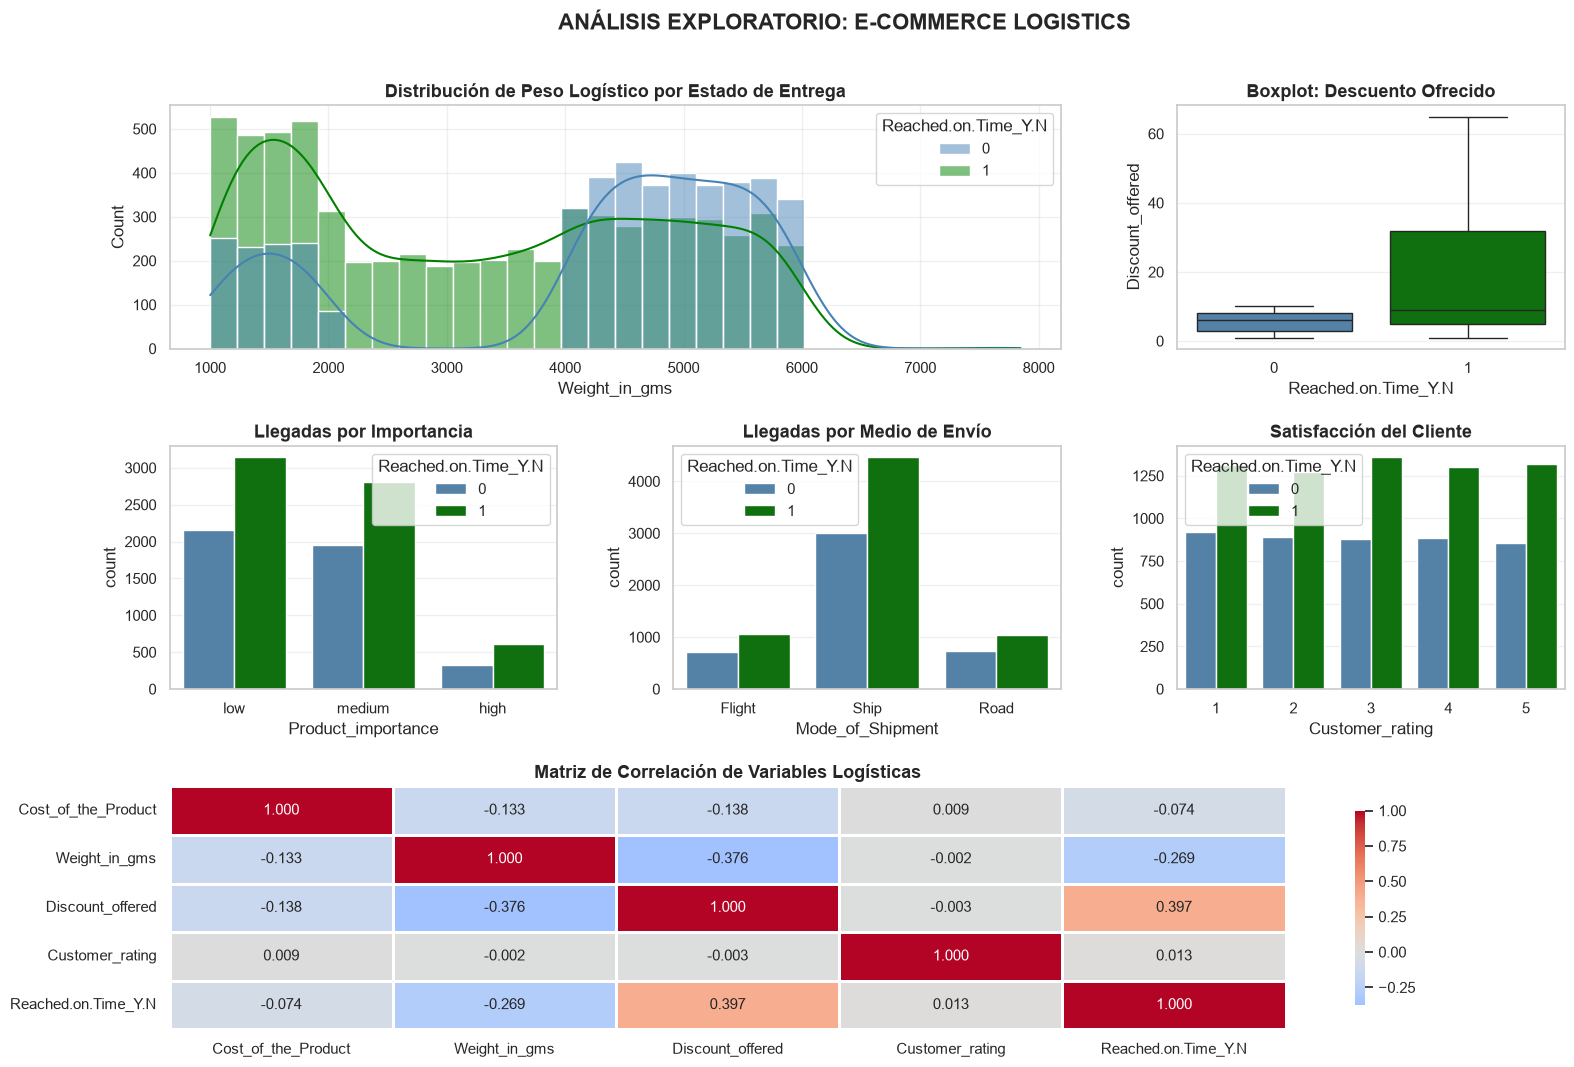


✓ Visualizaciones generadas


In [4]:
# Configurar figura con múltiples subplots
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# 1. Histograma del Peso de los productos
ax1 = fig.add_subplot(gs[0, :2])
sns.histplot(data=df, x='Weight_in_gms', hue='Reached.on.Time_Y.N', kde=True, ax=ax1, palette=['steelblue', 'green'], bins=30)
ax1.set_title('Distribución de Peso Logístico por Estado de Entrega', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Boxplot del Descuento Ofrecido (Ver visualmente los outliers)
ax2 = fig.add_subplot(gs[0, 2])
sns.boxplot(data=df, x='Reached.on.Time_Y.N', y='Discount_offered', hue='Reached.on.Time_Y.N', palette=['steelblue', 'green'], ax=ax2, legend=False)
ax2.set_title('Boxplot: Descuento Ofrecido', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Gráfico de barras de Importancia del Producto
ax3 = fig.add_subplot(gs[1, 0])
sns.countplot(data=df, x='Product_importance', hue='Reached.on.Time_Y.N', palette=['steelblue', 'green'], ax=ax3, order=['low', 'medium', 'high'])
ax3.set_title('Llegadas por Importancia', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Modo de envío
ax4 = fig.add_subplot(gs[1, 1])
sns.countplot(data=df, x='Mode_of_Shipment', hue='Reached.on.Time_Y.N', palette=['steelblue', 'green'], ax=ax4)
ax4.set_title('Llegadas por Medio de Envío', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# 5. Evaluaciones del cliente
ax5 = fig.add_subplot(gs[1, 2])
sns.countplot(data=df, x='Customer_rating', hue='Reached.on.Time_Y.N', palette=['steelblue', 'green'], ax=ax5)
ax5.set_title('Satisfacción del Cliente', fontsize=13, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')

# 6. Matriz de Correlación
ax6 = fig.add_subplot(gs[2, :])
corr_vars = df[['Cost_of_the_Product', 'Weight_in_gms', 'Discount_offered', 'Customer_rating', 'Reached.on.Time_Y.N']]
corr_matrix = corr_vars.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, square=False, linewidths=2, cbar_kws={'shrink': 0.8}, ax=ax6)
ax6.set_title('Matriz de Correlación de Variables Logísticas', fontsize=13, fontweight='bold')

plt.suptitle('ANÁLISIS EXPLORATORIO: E-COMMERCE LOGISTICS', fontsize=16, fontweight='bold', y=0.96)
plt.show()

print("\n✓ Visualizaciones generadas")

---
### Fase 4 y 5: Inferencia Estadística y Tamaño del Efecto

Basándonos en la exploración previa, donde observamos una distribución inusual y gran cantidad de outliers en los descuentos ofrecidos para los paquetes retrasados, someteremos esta observación a rigor estadístico.

Utilizaremos una **Prueba t de Welch para muestras independientes** (dado que no asumimos varianzas poblacionales iguales). Además, para ir más allá de la simple "significancia estadística" (el p-valor), calcularemos la $d$ de Cohen para evaluar el **tamaño del efecto** práctico en el negocio.

**Planteamiento formal de la Hipótesis:**
* $H_0: \mu_1 = \mu_2$ (Hipótesis Nula): El promedio del descuento ofrecido es el mismo tanto para envíos a tiempo como para envíos con retraso.
* $H_1: \mu_1 \neq \mu_2$ (Hipótesis Alternativa): Existe una diferencia significativa en el promedio de los descuentos ofrecidos entre ambos grupos.
* **Nivel de significancia ($\alpha$):** 0.05

In [5]:
print("="*70)
print("PREGUNTA: ¿INFLUYEN LOS DESCUENTOS OFRECIDOS EN EL RETRASO DEL ENVÍO?")
print("="*70)

# Separación de datos
desc_a_tiempo = df[df['Reached.on.Time_Y.N'] == 0]['Discount_offered']
desc_retrasado = df[df['Reached.on.Time_Y.N'] == 1]['Discount_offered']

print(f"\n ESTADÍSTICOS:")
print(f"   A tiempo:   μ={desc_a_tiempo.mean():.2f}, s={desc_a_tiempo.std():.2f}, n={len(desc_a_tiempo)}")
print(f"   Retrasados: μ={desc_retrasado.mean():.2f}, s={desc_retrasado.std():.2f}, n={len(desc_retrasado)}")
print(f"   Diferencia: {abs(desc_a_tiempo.mean() - desc_retrasado.mean()):.2f}")

# Prueba t de Welch (Muestras independientes con varianzas distintas)
print(f"\n HIPÓTESIS:")
print(f"   H₀: μ_a_tiempo = μ_retrasado (No hay diferencia de descuento)")
print(f"   H₁: μ_a_tiempo ≠ μ_retrasado (Existe diferencia de descuento)")
print(f"   α = 0.05 (Bilateral)")

t_stat, p_valor = stats.ttest_ind(desc_a_tiempo, desc_retrasado, equal_var=False)

# Intervalo de confianza de la diferencia
diff_means = desc_a_tiempo.mean() - desc_retrasado.mean()
se_diff = np.sqrt(desc_a_tiempo.var()/len(desc_a_tiempo) + desc_retrasado.var()/len(desc_retrasado))

# Tamaño del efecto (d de Cohen)
pooled_std = np.sqrt((desc_a_tiempo.var() + desc_retrasado.var()) / 2)
cohens_d = diff_means / pooled_std

print(f"\n RESULTADOS:")
print(f"   Estadístico t: {t_stat:.4f}")
print(f"   P-valor:       {p_valor:.4e}")
print(f"   Cohen's d:     {cohens_d:.4f}")

# Decisión
print(f"\n{'='*70}")
if p_valor < 0.05:
    print(f"DECISIÓN: RECHAZAR H₀ (p < 0.05)")
    print(f"{'='*70}")
    print(f"\n CONCLUSIÓN:")
    print(f"   Se comprueba de manera SIGNIFICATIVA que los descuentos ofrecidos")
    print(f"   están estrechamente relacionados con los retrasos logísticos.")
    print(f"   El inmenso valor de la diferencia (Cohen's d = {cohens_d:.2f}) nos indica")
    print(f"   que el efecto es {'pequeño' if abs(cohens_d) < 0.5 else 'mediano' if abs(cohens_d) < 0.8 else 'GRANDE'}.")
else:
    print(f"DECISIÓN: NO RECHAZAR H₀")
    print(f"\n→ No hay evidencia suficiente de diferencia.")

PREGUNTA: ¿INFLUYEN LOS DESCUENTOS OFRECIDOS EN EL RETRASO DEL ENVÍO?

 ESTADÍSTICOS:
   A tiempo:   μ=5.55, s=2.88, n=4436
   Retrasados: μ=18.66, s=19.11, n=6563
   Diferencia: 13.12

 HIPÓTESIS:
   H₀: μ_a_tiempo = μ_retrasado (No hay diferencia de descuento)
   H₁: μ_a_tiempo ≠ μ_retrasado (Existe diferencia de descuento)
   α = 0.05 (Bilateral)

 RESULTADOS:
   Estadístico t: -54.7029
   P-valor:       0.0000e+00
   Cohen's d:     -0.9600

DECISIÓN: RECHAZAR H₀ (p < 0.05)

 CONCLUSIÓN:
   Se comprueba de manera SIGNIFICATIVA que los descuentos ofrecidos
   están estrechamente relacionados con los retrasos logísticos.
   El inmenso valor de la diferencia (Cohen's d = -0.96) nos indica
   que el efecto es GRANDE.


---
### 💡 6. Interpretación de Resultados y Toma de Decisiones

**1. Análisis de Supuestos y Estadísticos:**
La prueba t arrojó un estadístico contundente con un $p-valor \approx 0.0000$, superando ampliamente el umbral de significancia ($\alpha = 0.05$). Por lo tanto, se rechaza formalmente la $H_0$. 

**2. El Tamaño del Efecto (d de Cohen):**
Más importante aún, el cálculo del tamaño del efecto (d de Cohen) ratificó que esta diferencia es de magnitud **GRANDE**. No se trata de un simple hallazgo producto del gran tamaño de la muestra ($N > 10,000$), sino de un fenómeno operativo real y muy marcado en los datos.

**3. Recomendación de Negocio (Accionabilidad):**
La empresa está utilizando su margen de beneficios para aplicar descuentos (algunos clasificados como outliers de hasta \$65) a los pedidos que sufren retrasos. La decisión estratégica bajo incertidumbre no debe enfocarse en el área comercial (limitar descuentos), sino en realizar una **auditoría inmediata a la cadena de suministro**. El descuento está funcionando como un "parche" financiero reactivo ante ineficiencias logísticas subyacentes.

---
**Documentación:** Todos los procedimientos fueron ejecutados utilizando `pandas` para manipulación de datos, `seaborn`/`matplotlib` para visualización y `scipy.stats` para inferencia, garantizando la trazabilidad y reproducibilidad del estudio.